In [1]:
import sys
sys.path.insert(0, '/home/shivamsingh/documents/566FinalProject')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler

from evaluation import evaluate_dataset, print_results_table
from plotting import plot_2d_embeddings, plot_time_metrics, plot_memory_metrics, plot_combined_dual_axis

In [2]:
RANDOM_SEED = 42
N_SAMPLES = 1500

X_raw, t = make_swiss_roll(n_samples=N_SAMPLES, noise=0.1, random_state=RANDOM_SEED)
X_swiss = StandardScaler().fit_transform(X_raw).astype(np.float32)
y_swiss = np.floor((t - t.min()) / (t.max() - t.min()) * 8).clip(0, 7).astype(np.int64)

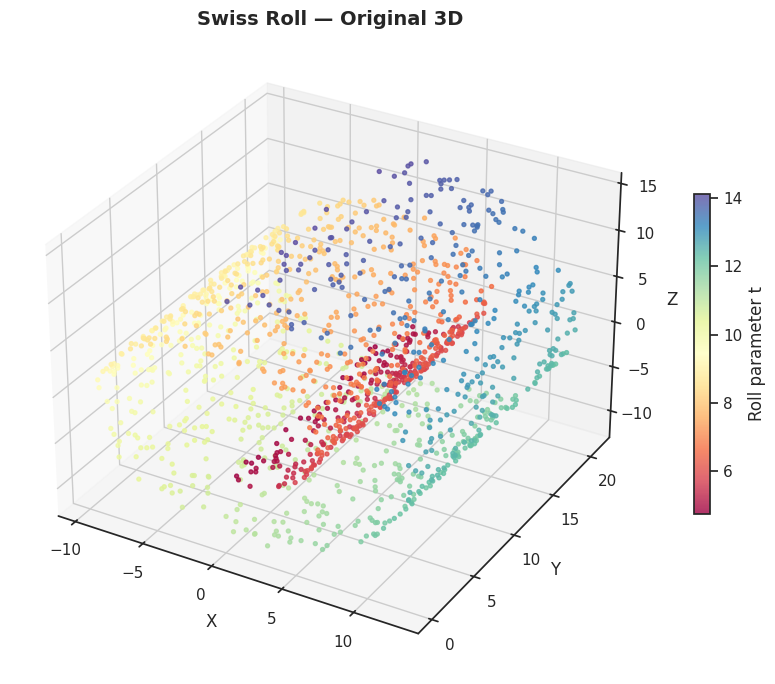

In [3]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], c=t, cmap='Spectral', s=8, alpha=0.8)
fig.colorbar(scatter, ax=ax, shrink=0.5, label='Roll parameter t')
ax.set_title('Swiss Roll — Original 3D', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.savefig('figures/swiss_roll_3d.png', dpi=300)
plt.show()

In [4]:
baseline_swiss, dim_data_swiss = evaluate_dataset("Swiss Roll", X_swiss, y_swiss, num_runs=3, dimensions=[2])

In [5]:
print_results_table({"Swiss Roll": dim_data_swiss}, {"Swiss Roll": baseline_swiss})


  Swiss Roll  |  Baseline — Acc: 0.9767 ±0.0027  F1: 0.9766 ±0.0030
+------------------+------+----------+----------+----------+----------+----------+----------+----------+----------+
|Model             |Dims  |Time      |±         |Mem       |±         |Acc       |±         |F1        |±         |
+------------------+------+----------+----------+----------+----------+----------+----------+----------+----------+
|PCA               |2     |0.00      |0.00      |0.0       |0.0       |0.5222    |0.0220    |0.4417    |0.0159    |
|Isomap            |2     |0.26      |0.00      |17.1      |0.2       |0.9300    |0.0082    |0.9288    |0.0084    |
|UMAP              |2     |12.07     |10.47     |17.5      |8.9       |0.9144    |0.0193    |0.9130    |0.0195    |
|t-SNE             |2     |7.33      |0.05      |6.8       |0.0       |0.8433    |0.0756    |0.8406    |0.0761    |
|VAE               |2     |2.59      |2.13      |23.2      |32.7      |0.4967    |0.0384    |0.4631    |0.0232    |
+--

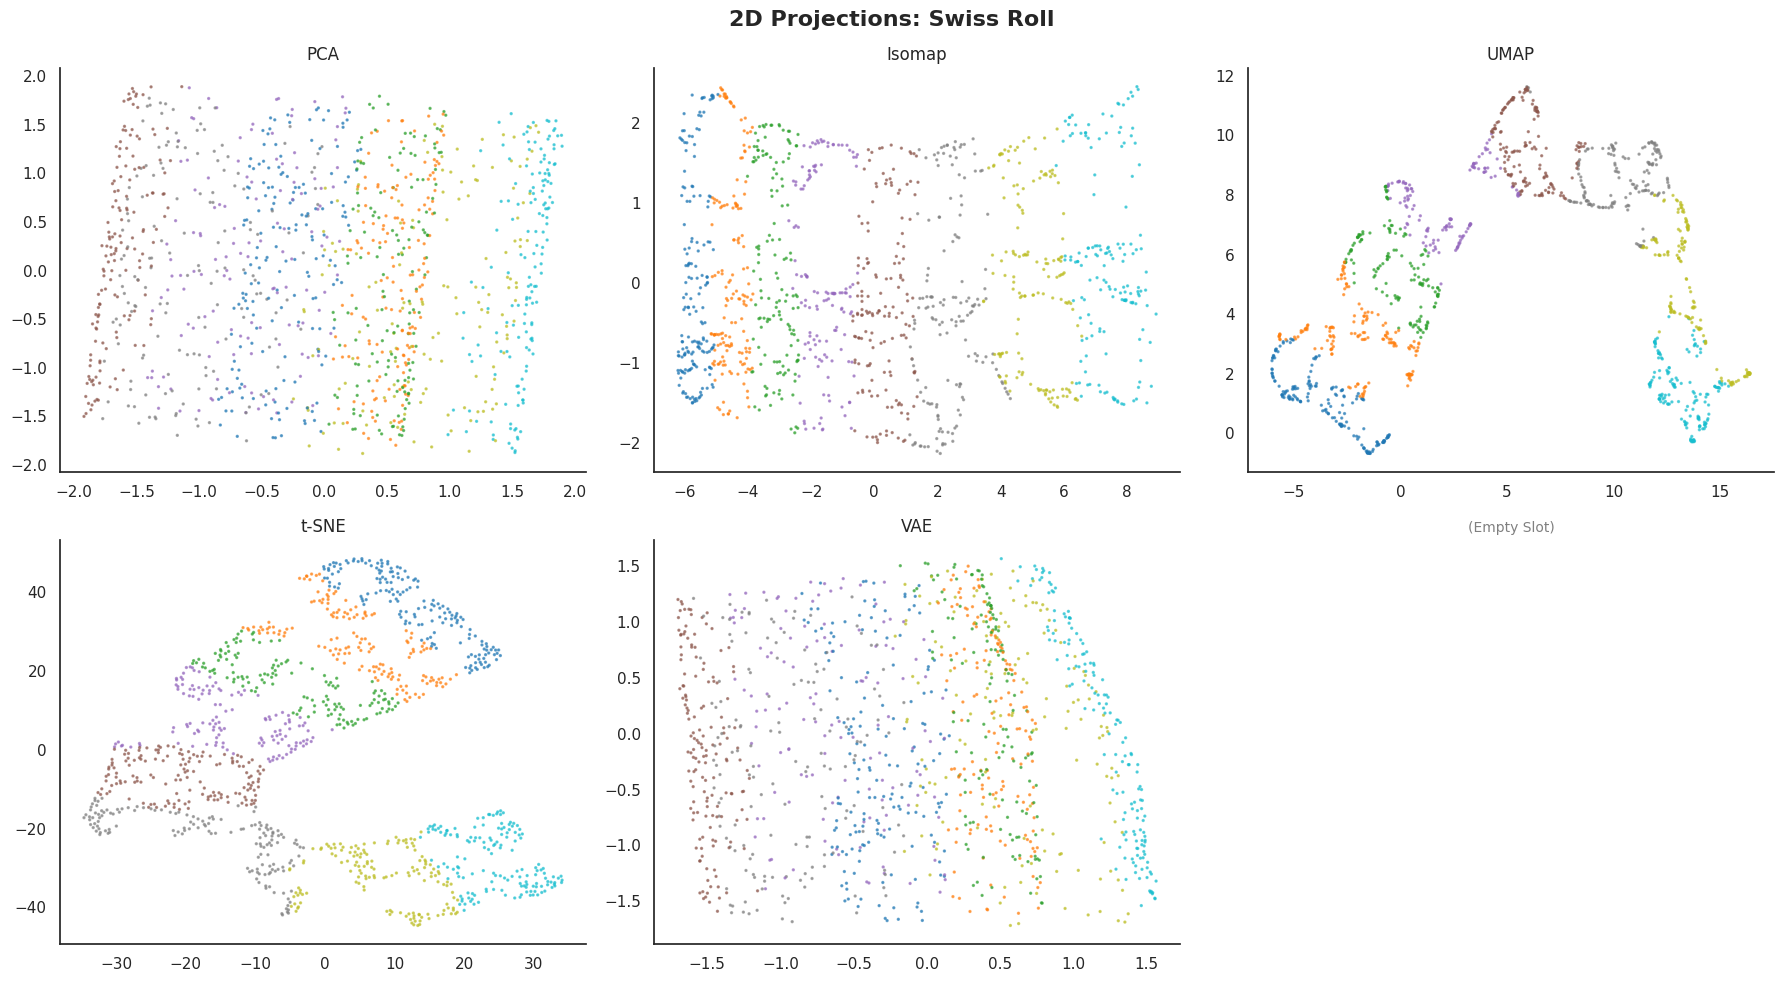

In [6]:
plot_2d_embeddings({"Swiss Roll": dim_data_swiss[2]})

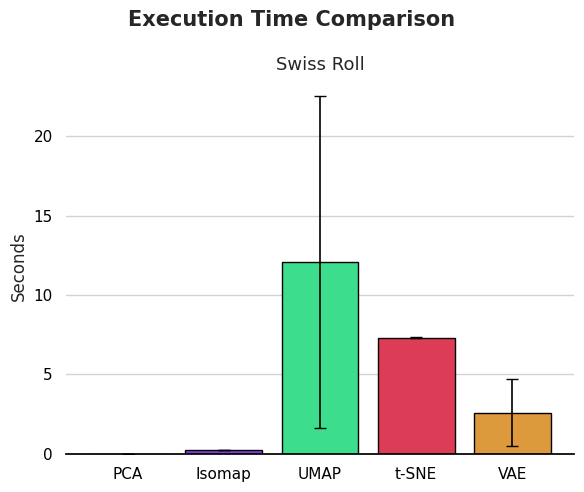

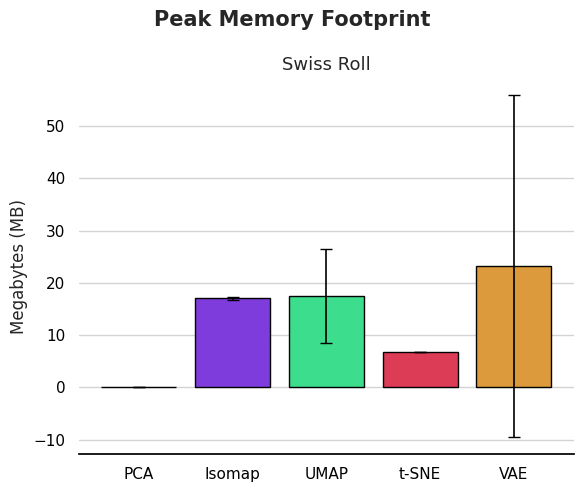

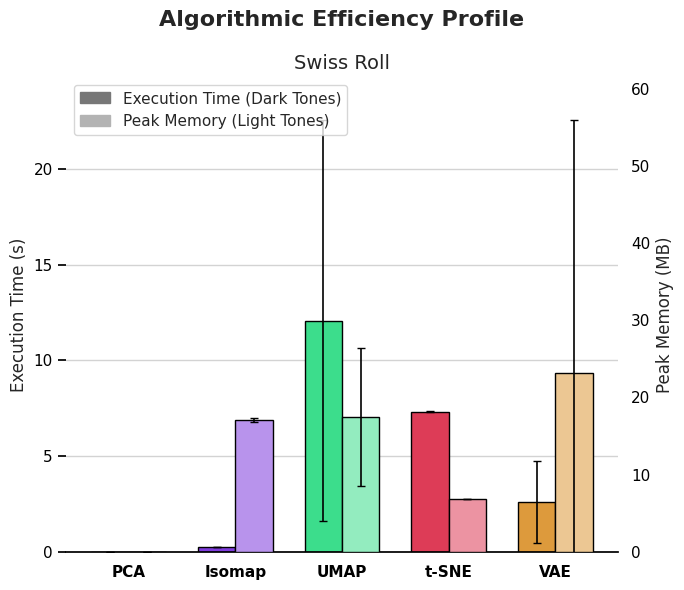

In [7]:
d2_perf = {
    "Swiss Roll": {
        model_name: {**data, "time": data["time_mean"], "memory_mb": data["memory_mean"]}
        for model_name, data in dim_data_swiss[2].items()
    }
}
plot_time_metrics(d2_perf)
plot_memory_metrics(d2_perf)
plot_combined_dual_axis(d2_perf)